# Imports

In [18]:
#!pip install -r ../requirements.txt

In [19]:
from pysus import SINAN
import pandas as pd

# Data acquisition

In [20]:
sinan = SINAN().load()

In [21]:
files = sinan.get_files(dis_code=['MALA'])

In [22]:
parquet = sinan.download(files)

98243it [00:00, 13164047.28it/s]      


In [23]:
df = None
for p in parquet:
    p.to_dataframe()
    df = pd.concat([df, p.to_dataframe()])

In [24]:
display(df)

,ID_MUNICIP,ID_UNIDADE,DT_NOTIFIC,CS_RACA,CS_ESCOLAR,NU_ANO,SEM_NOT,SG_UF_NOT,ID_REGIONA,DT_SIN_PRI,...,DT_ENCERRA,DT_DIGITA,DT_TRANSUS,DT_TRANSDM,DT_TRANSSM,DT_TRANSRM,DT_TRANSRS,DT_TRANSSE,NU_LOTE_V,NU_LOTE_H
0,2708006,2004054,2004-01-26,4,3,2004,042004,AL,008,2004-01-20,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
1,2704302,0008133,2004-02-04,,,2004,052004,AL,,2004-01-02,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
2,2704302,2720035,2004-01-06,4,9,2004,012004,AL,001,2003-12-30,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
3,2704302,2720035,2004-01-07,1,9,2004,012004,AL,001,2004-01-01,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
4,2704302,2720035,2004-01-02,4,9,2004,532003,AL,001,2004-01-01,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2266,320530,11746,2024-12-16,4,<NA>,2024,202450,32,32002,2024-12-16,...,20241218,20241216,,,,,,,,
2267,320520,2445069,2024-12-27,4,<NA>,2024,202451,32,32002,2024-12-25,...,20250101,20241227,,,,,,,,
2268,320530,11800,2024-12-30,4,<NA>,2024,202452,32,32002,2024-12-29,...,20241231,20241230,,,,,,,,
2269,320530,11738,2024-11-17,3,<NA>,2024,202446,32,32002,2024-11-16,...,20250108,20241117,,,,,,,,


In [25]:
df.to_csv('../data/malaria.csv', index=False)

# Contextualização

O presente trabalho utiliza dados do Sistema de Informação de Agravos de Notificação (**Sinan**). Este é o sistema informatizado do Ministério da Saúde utilizado no Brasil para registrar e processar dados de doenças e agravos de notificação compulsória. Ele alimenta a vigilância epidemiológica com dados das unidades de saúde para identificar riscos, planejar intervenções e definir prioridades de saúde pública em nível municipal, estadual e federal

o caso de estudo é da doença da **malária** que é uma doença infecciosa febril aguda, potencialmente grave, causada por parasitas do gênero Plasmodium e transmitida pela picada da fêmea infectada do mosquito Anopheles (mosquito-prego). Comum em áreas tropicais, provoca sintomas como febre alta, calafrios, dores de cabeça e no corpo. A doença tem cura, mas exige tratamento rápido para evitar complicações fatais.


# EDA

In [26]:
print("Shape:", df.shape)
df.info()
df.describe()

Shape: (68320, 102)
<class 'pandas.core.frame.DataFrame'>
Index: 68320 entries, 0 to 2270
Columns: 102 entries, ID_MUNICIP to NU_LOTE_H
dtypes: object(2), string(100)
memory usage: 53.7+ MB


,ID_MUNICIP,ID_UNIDADE,DT_NOTIFIC,CS_RACA,CS_ESCOLAR,NU_ANO,SEM_NOT,SG_UF_NOT,ID_REGIONA,DT_SIN_PRI,...,DT_ENCERRA,DT_DIGITA,DT_TRANSUS,DT_TRANSDM,DT_TRANSSM,DT_TRANSRM,DT_TRANSRS,DT_TRANSSE,NU_LOTE_V,NU_LOTE_H
count,68320,68320,68320,68320,12026,68320,68320,68320,68320,68320,...,56294,56294,56294,56294,56294,56294,56294,56294,56294,56294
unique,2642,6183,7216,7,8,21,1203,45,300,7764,...,591,4826,1525,668,3989,1,847,569,1,1
top,330455,2506661,2018-08-09,4,3,2018,201832,32,,2018-08-09,...,,,,,,,,,,
freq,3676,2805,464,28141,2996,7939,1917,9654,10892,437,...,55101,216,53828,55126,34713,56294,53848,51751,56294,56294


In [27]:
lista_de_colunas = df.columns.tolist()
print(lista_de_colunas)#PMALARIA AMALARIA??? - nada sobre no pdf de descrição do dataset, provavelmente não é tão relevante

['ID_MUNICIP', 'ID_UNIDADE', 'DT_NOTIFIC', 'CS_RACA', 'CS_ESCOLAR', 'NU_ANO', 'SEM_NOT', 'SG_UF_NOT', 'ID_REGIONA', 'DT_SIN_PRI', 'SEM_PRI', 'NU_IDADE', 'CS_SEXO', 'ID_MN_RESI', 'SG_UF', 'ID_PAIS', 'ID_DG_NOT', 'ID_EV_NOT', 'ANT_DT_INV', 'OCUPACAO', 'TRANSFU', 'DTTRANSFU', 'UTRANSFU', 'UFTRANSFU', 'PTRANSFU', 'MTRANSFU', 'PUSUARIO', 'PMALARIA', 'AMALARIA', 'ASSINTOM', 'FEBRE', 'CALAFRIO', 'SUDORESE', 'CLI_OUTRO', 'CD_OUTRO', 'GESTANTE', 'HOSPITAL', 'DINTERNA', 'UFINTERNA', 'MINTERNA', 'DEXAME', 'PMM', 'PCRUZ', 'RESULT', 'CLOROQ', 'PRIMAQ', 'TETRAC', 'MEFLOQ', 'ARTESU', 'QUININO', 'ARTEM', 'CLIND', 'CLOROQI', 'QUININOI', 'ARTEI', 'ARTEMI', 'CLINDI', 'DOXOCI', 'SOUTROS', 'DTRATA', 'CON_CLASSI', 'CON_CONFIR', 'CON_INF_MU', 'CON_INF_UF', 'CON_INF_PA', 'CON_DOENCA', 'CON_EVOLUC', 'CON_DT_OBI', 'CON_DT_ENC', 'IN_VINCULA', 'NDUPLIC', 'TP_NOT', 'ID_AGRAVO', 'ANO_NASC', 'NU_IDADE_N', 'CS_GESTANT', 'CS_ESCOL_N', 'ID_RG_RESI', 'DT_INVEST', 'ID_OCUPA_N', 'CLASSI_FIN', 'AT_ATIVIDA', 'AT_LAMINA', 'A

### 1. Identificação da Notificação e Tempo
Dados que situam o registro no tempo e no sistema administrativo.

Colunas: NU_ANO, SEM_NOT, DT_NOTIFIC, TP_NOT, ID_AGRAVO, DT_DIGITA, ID_MUNICIP, ID_UNIDADE, ID_REGIONA, SG_UF_NOT.

### 2. Perfil Demográfico do Paciente
Informações sobre quem é a pessoa notificada.

Colunas: NU_IDADE, NU_IDADE_N, ANO_NASC, CS_SEXO, CS_RACA, CS_ESCOLAR, CS_ESCOL_N, GESTANTE, CS_GESTANT, OCUPACAO, ID_OCUPA_N.

### 3. Local de Residência e Fluxo Geográfico
Onde o paciente mora e onde ele pode ter sido infectado.

Colunas: ID_MN_RESI, ID_RG_RESI, SG_UF, ID_PAIS.

### 4. Dados Clínicos e Sintomas
O "quadro" do paciente no momento da suspeita.

Colunas: DT_SIN_PRI, SEM_PRI, FEBRE, CALAFRIO, SUDORESE, ASSINTOM, CLI_OUTRO, CD_OUTRO, AT_SINTOMA.

### 5. Histórico Epidemiológico e Investigação
Fatores de risco e antecedentes de exposição.

Colunas: ANT_DT_INV, DT_INVEST, TRANSFU, DTTRANSFU, UTRANSFU, UFTRANSFU, PTRANSFU, MTRANSFU, PMALARIA, AMALARIA, AT_ATIVIDA, AT_LAMINA.

### 6. Diagnóstico Laboratorial
Resultados de exames e a confirmação da doença.

Colunas: DEXAME, PMM, PCRUZ, RESULT, CLASSI_FIN, CON_CLASSI, CON_CONFIR.

### 7.  Tratamento Ministrado
Medicamentos e esquemas terapêuticos utilizados.

Colunas: DTRATA, CLOROQ, PRIMAQ, TETRAC, MEFLOQ, ARTESU, QUININO, ARTEM, CLIND, CLOROQI, QUININOI, ARTEI, ARTEMI, CLINDI, DOXOCI, SOUTROS, TRA_ESQUEM, DSTRAESQUE.

### 8. Internação e Local provável de Infecção (LPI)
Dados sobre gravidade e origem da infecção.

Colunas: HOSPITAL, DINTERNA, UFINTERNA, MINTERNA, TPAUTOCTO, COUFINF, COPAISINF, COMUNINF, LOC_INF.

### 9. Conclusão e Desfecho do Caso
Como o caso foi encerrado (cura, óbito, duplicidade).

Colunas: CON_EVOLUC, CON_DT_OBI, CON_DT_ENC, DT_ENCERRA, CON_DOENCA, IN_VINCULA, NDUPLIC.

### 10. Metadados e Controle do Sistema (Logs)
Colunas técnicas para rastreamento de lotes e transferências de dados.

Colunas: DT_TRANSUS, DT_TRANSDM, DT_TRANSSM, DT_TRANSRM, DT_TRANSRS, DT_TRANSSE, NU_LOTE_I, NU_LOTE_V, NU_LOTE_H, PUSUARIO.

In [28]:
df.describe()

,ID_MUNICIP,ID_UNIDADE,DT_NOTIFIC,CS_RACA,CS_ESCOLAR,NU_ANO,SEM_NOT,SG_UF_NOT,ID_REGIONA,DT_SIN_PRI,...,DT_ENCERRA,DT_DIGITA,DT_TRANSUS,DT_TRANSDM,DT_TRANSSM,DT_TRANSRM,DT_TRANSRS,DT_TRANSSE,NU_LOTE_V,NU_LOTE_H
count,68320,68320,68320,68320,12026,68320,68320,68320,68320,68320,...,56294,56294,56294,56294,56294,56294,56294,56294,56294,56294
unique,2642,6183,7216,7,8,21,1203,45,300,7764,...,591,4826,1525,668,3989,1,847,569,1,1
top,330455,2506661,2018-08-09,4,3,2018,201832,32,,2018-08-09,...,,,,,,,,,,
freq,3676,2805,464,28141,2996,7939,1917,9654,10892,437,...,55101,216,53828,55126,34713,56294,53848,51751,56294,56294


In [29]:
df.isna().sum()

ID_MUNICIP        0
ID_UNIDADE        0
DT_NOTIFIC        0
CS_RACA           0
CS_ESCOLAR    56294
              ...  
DT_TRANSRM    12026
DT_TRANSRS    12026
DT_TRANSSE    12026
NU_LOTE_V     12026
NU_LOTE_H     12026
Length: 102, dtype: int64

ideias para análise exploratória

### Análise Temporal
O objetivo aqui é identificar sazonalidade e tendências de crescimento ou queda da doença.

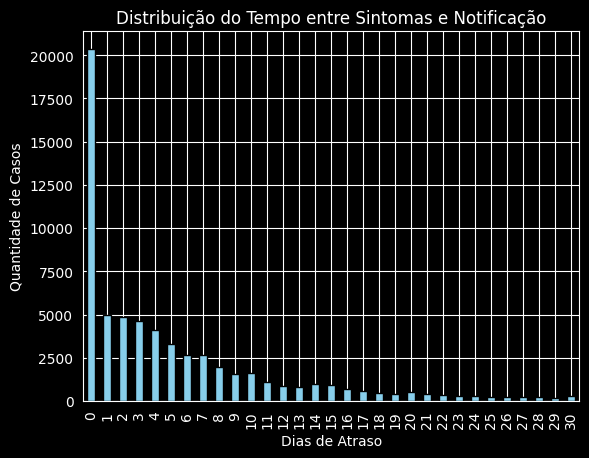

In [30]:
import pandas as pd
import matplotlib.pyplot as plt

# Convertendo para datetime (ajuste os nomes se necessário)
df['DT_NOTIFIC'] = pd.to_datetime(df['DT_NOTIFIC'])
df['DT_SIN_PRI'] = pd.to_datetime(df['DT_SIN_PRI'])

# Calculando a diferença em dias
df['DIAS_ATRASO'] = (df['DT_NOTIFIC'] - df['DT_SIN_PRI']).dt.days

# remoção de valores negativos (erros de digitação)
# e outliers extremos (ex: mais de 30 dias) para o gráfico não ficar poluído
df_filtrado = df[(df['DIAS_ATRASO'] >= 0) & (df['DIAS_ATRASO'] <= 30)]

# Contando a frequência de cada dia
contagem_atraso = df_filtrado['DIAS_ATRASO'].value_counts().sort_index()

# Plotando o gráfico de barras
contagem_atraso.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Distribuição do Tempo entre Sintomas e Notificação')
plt.xlabel('Dias de Atraso')
plt.ylabel('Quantidade de Casos')
plt.show()


/tmp/ipykernel_16222/4118066575.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='CS_SEXO', palette='Pastel1', ax=ax[0])


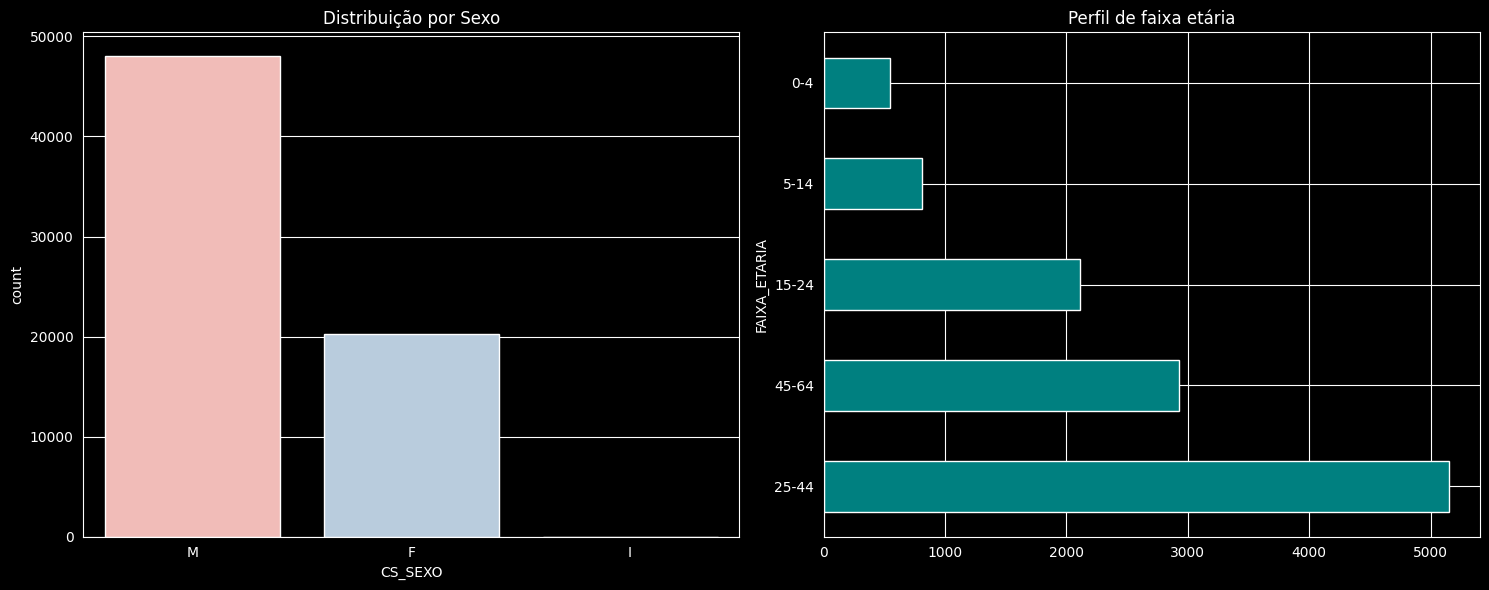

In [31]:
def converter_idade(valor):
    if pd.isna(valor) or not isinstance(valor, str):
        return None

    prefixo = valor[0]
    try:
        num = int(valor[1:])
    except:
        return None # Trata casos como '2002' que não seguem o padrão letra+número

    if prefixo == 'A':
        return num
    elif prefixo == 'M':
        return num / 12
    elif prefixo == 'D':
        return num / 365
    else:
        return None

df['IDADE_LIMPA'] = df['NU_IDADE'].apply(converter_idade)

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Criando Faixas Etárias
bins = [0, 5, 14, 25, 45, 65, 120]
labels = ['0-4', '5-14', '15-24', '25-44', '45-64', '65+']
df['FAIXA_ETARIA'] = pd.cut(df['IDADE_LIMPA'], bins=bins, labels=labels)

# 2. Setup do Layout (1 linha, 2 colunas)
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

# Gráfico A: Distribuição por Sexo
sns.countplot(data=df, x='CS_SEXO', palette='Pastel1', ax=ax[0])
ax[0].set_title('Distribuição por Sexo')

# Gráfico B: Escolaridade (Top 5)
df['FAIXA_ETARIA'].value_counts().head(5).plot(kind='barh', color='teal', ax=ax[1])
ax[1].set_title('Perfil de faixa etária')

plt.tight_layout()
plt.show()

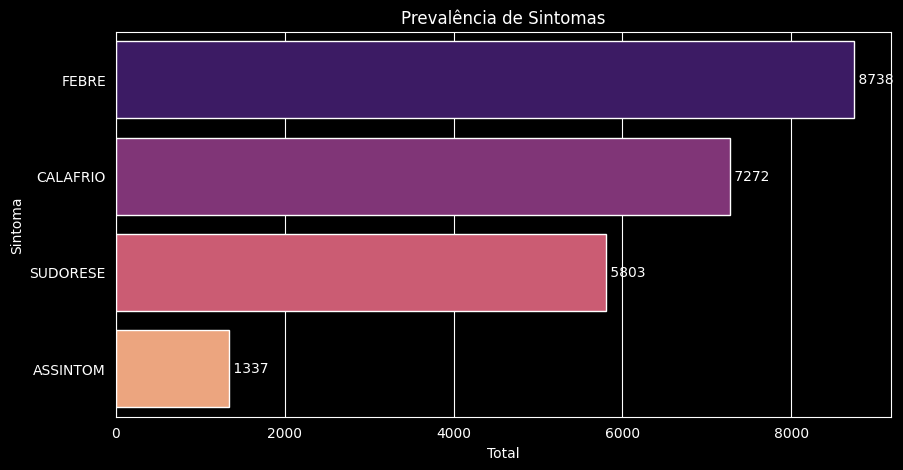

In [32]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

colunas_sintomas = ['FEBRE', 'CALAFRIO', 'SUDORESE', 'ASSINTOM']

# Criando a contagem de forma mais "agressiva"
contagem_sintomas = {}
for col in colunas_sintomas:
    if col in df.columns:
        # 1. Garante que é string e remove espaços (ex: ' 1 ' vira '1')
        # 2. Conta quantos são '1' ou 1
        serie_limpa = df[col].astype(str).str.strip()
        contagem_sintomas[col] = (serie_limpa == '1').sum()
    else:
        print(f"Aviso: Coluna {col} não encontrada no CSV!")

# Criando o DataFrame para o gráfico
df_sintomas = pd.DataFrame(list(contagem_sintomas.items()), columns=['Sintoma', 'Total'])
df_sintomas = df_sintomas.sort_values(by='Total', ascending=False)

# Plot (Removendo o aviso de 'palette' usando o parâmetro 'hue')
plt.figure(figsize=(10, 5))
sns.barplot(data=df_sintomas, x='Total', y='Sintoma', hue='Sintoma', palette='magma', legend=False)

# Adicionando os números nas barras
for i, valor in enumerate(df_sintomas['Total']):
    plt.text(valor, i, f' {int(valor)}', va='center')

plt.title('Prevalência de Sintomas')
plt.show()

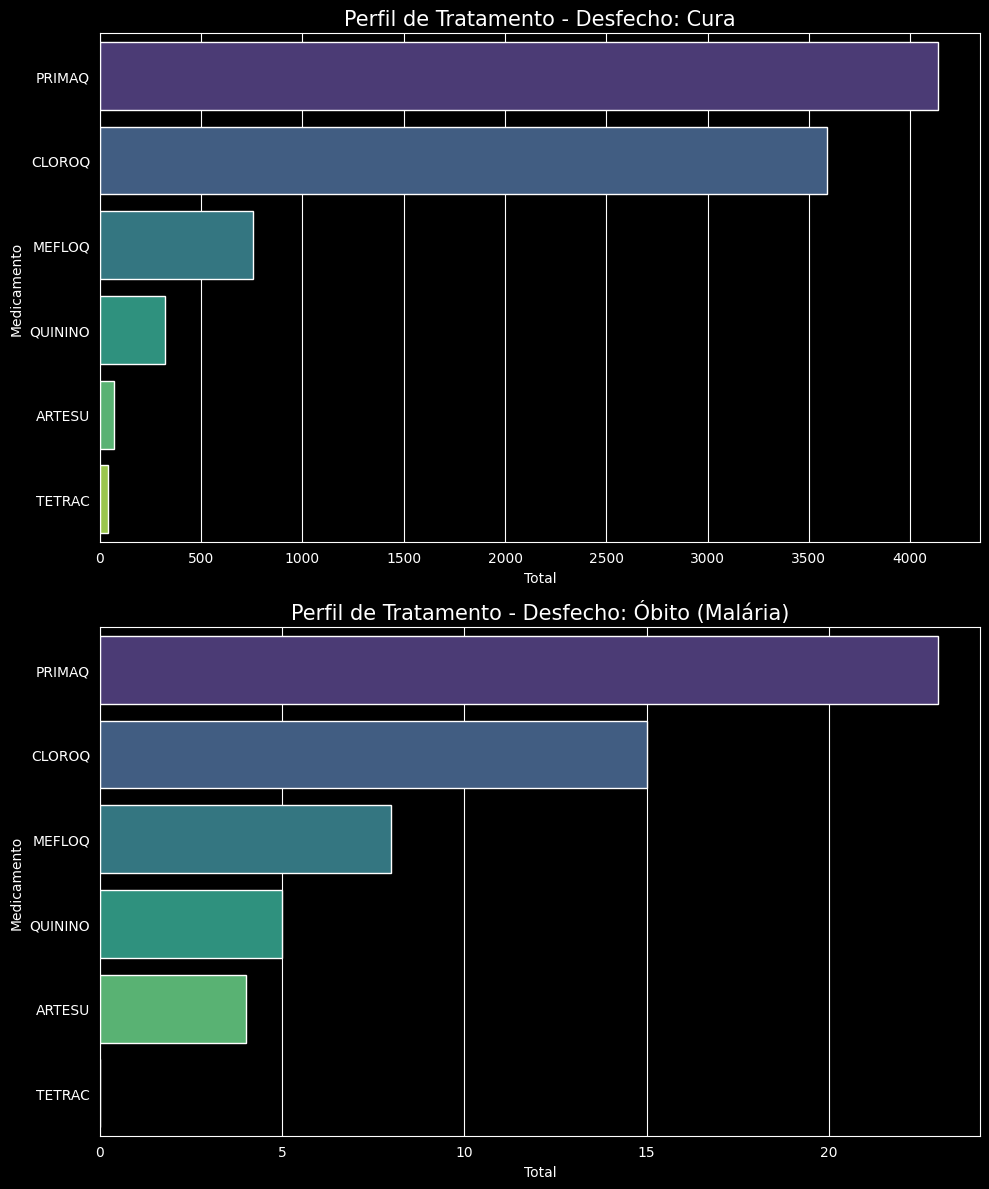

In [33]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Lista de tratamentos
colunas_tratamento = ['CLOROQ', 'PRIMAQ', 'TETRAC', 'MEFLOQ', 'ARTESU', 'QUININO']

# 2. Diagnóstico: Vamos ver o que realmente tem na coluna de desfecho
# Substitua 'CON_EVOLUC' pelo nome exato da coluna no seu dataframe
coluna_alvo = 'CON_EVOLUC'

# Convertemos para string para evitar problemas de tipo (1 vs 1.0 vs '1')
df[coluna_alvo] = df[coluna_alvo].astype(str).str.replace('.0', '', regex=False).str.strip()

mapa_desfechos = {
    '1': 'Cura',
    '2': 'Óbito (Malária)',
    '3': 'Óbito (Outros)',
    '4': 'Abandono'
}
df['DESFECHO_NOME'] = df[coluna_alvo].map(mapa_desfechos)

# Filtrar apenas desfechos que conseguimos mapear e que não são "nan"
df_validos = df[df['DESFECHO_NOME'].notna() & (df['DESFECHO_NOME'] != 'nan')]
desfechos_unicos = df_validos['DESFECHO_NOME'].unique()

# Verificação de segurança
if len(desfechos_unicos) == 0:
    print(f"ERRO: Nenhum desfecho encontrado na coluna {coluna_alvo}!")
    print("Valores únicos encontrados na coluna:", df[coluna_alvo].unique())
else:
    # 3. Criar a figura
    fig, axes = plt.subplots(nrows=len(desfechos_unicos), ncols=1,
                             figsize=(10, 6 * len(desfechos_unicos)))

    # Se houver apenas 1 gráfico, o axes não vem como lista
    if len(desfechos_unicos) == 1: axes = [axes]

    for i, desfecho in enumerate(desfechos_unicos):
        df_temp = df_validos[df_validos['DESFECHO_NOME'] == desfecho]

        contagem = {}
        for col in colunas_tratamento:
            if col in df.columns:
                # Conta tanto o número 1 quanto a string '1'
                contagem[col] = (df_temp[col].astype(str).str.strip() == '1').sum()

        df_plot = pd.DataFrame(contagem.items(), columns=['Medicamento', 'Total']).sort_values('Total', ascending=False)

        sns.barplot(data=df_plot, x='Total', y='Medicamento', ax=axes[i], palette='viridis', hue='Medicamento', legend=False)
        axes[i].set_title(f'Perfil de Tratamento - Desfecho: {desfecho}', fontsize=15)

    plt.tight_layout()
    plt.show()

A primaquina é um medicamento antimalárico fundamental para a cura radical de Plasmodium vivax e P. ovale, atuando nas formas latentes no fígado (hipnozoítos) e prevenindo recaídas. Geralmente usada com cloroquina, é indicada para o tratamento e profilaxia terminal da malária, sendo contraindicada na gravidez.

A cloroquina é um medicamento utilizado para tratar malária e doenças autoimunes como lúpus e artrite reumatoide

A mefloquina (comumente comercializada como Lariam ou produzida como genérico) é um medicamento antimalárico oral, derivado do quinino, usado para a prevenção e tratamento da malária, particularmente o Plasmodium falciparum.

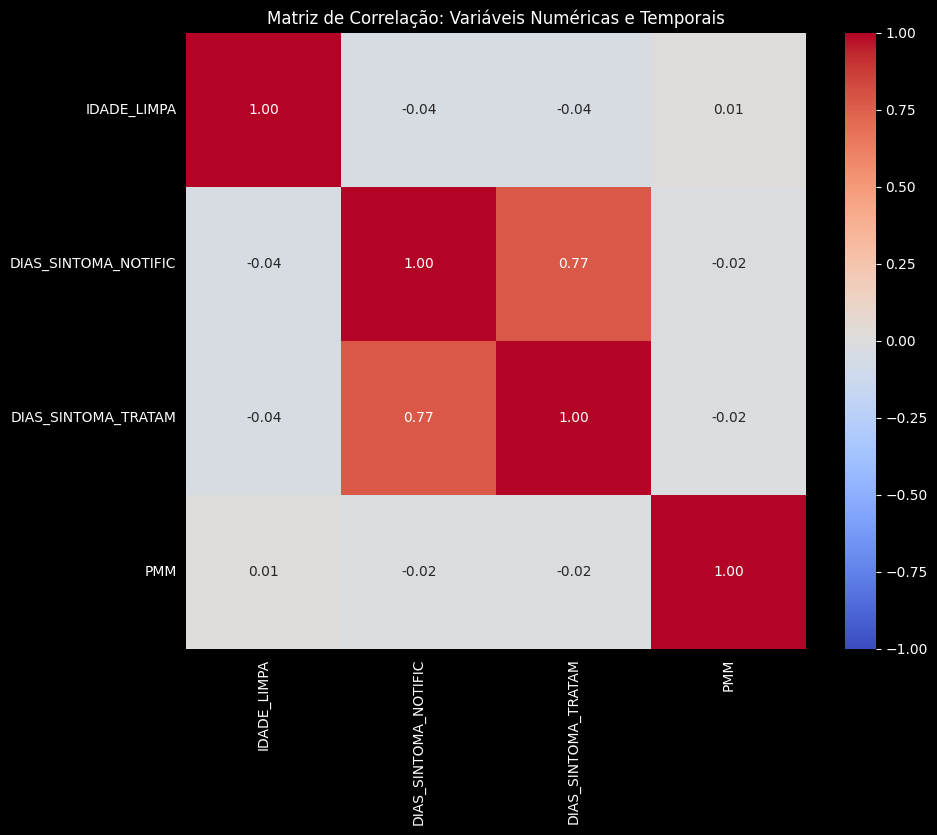

In [34]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Convertendo datas com 'coerce' para ignorar anos impossíveis (como o ano 1007)
# O format='mixed' ajuda o pandas a entender diferentes formatos de data se houver
df['DT_NOTIFIC'] = pd.to_datetime(df['DT_NOTIFIC'], errors='coerce')
df['DT_SIN_PRI'] = pd.to_datetime(df['DT_SIN_PRI'], errors='coerce')
df['DTRATA'] = pd.to_datetime(df['DTRATA'], errors='coerce')

# 2. Calculando os atrasos em dias
df['DIAS_SINTOMA_NOTIFIC'] = (df['DT_NOTIFIC'] - df['DT_SIN_PRI']).dt.days
df['DIAS_SINTOMA_TRATAM'] = (df['DTRATA'] - df['DT_SIN_PRI']).dt.days

# 3. Limpeza de Outliers (Importante para a correlação não ser destruída por erros)
# Removemos dias negativos ou atrasos absurdos (ex: > 365 dias)
df_corr = df[
    (df['DIAS_SINTOMA_NOTIFIC'] >= 0) & (df['DIAS_SINTOMA_NOTIFIC'] <= 365) &
    (df['DIAS_SINTOMA_TRATAM'] >= 0) & (df['DIAS_SINTOMA_TRATAM'] <= 365)
].copy()

# 4. Selecionando colunas numéricas
colunas_corr = ['IDADE_LIMPA', 'DIAS_SINTOMA_NOTIFIC', 'DIAS_SINTOMA_TRATAM']

# Adiciona PMM se ela for numérica
if 'PMM' in df.columns:
    df_corr['PMM'] = pd.to_numeric(df_corr['PMM'], errors='coerce')
    colunas_corr.append('PMM')

# 5. Gerando a Matriz
plt.figure(figsize=(10, 8))
matriz = df_corr[colunas_corr].corr()

sns.heatmap(matriz, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Matriz de Correlação: Variáveis Numéricas e Temporais')
plt.show()

In [35]:
# Mantendo as colunas importantes antes da remoção, mesmo se possuírem mais de 80% <NA>

old_df = df.copy()

cols_importantes = [
    "DT_NOTIFIC",
    "SG_UF_NOT",
    "ID_MUNICIP",
    "NU_IDADE_N",
    "CS_SEXO"
]

# calcular proporção de NaN
missing_ratio = df.isnull().mean()

# definir threshold
threshold = 0.8

# colunas para remover (exceto importantes)
cols_removidas = missing_ratio[
    (missing_ratio >= threshold) & (~missing_ratio.index.isin(cols_importantes))
].index

# colunas mantidas
cols_mantidas = df.columns.difference(cols_removidas)

# logs
print(f"Total de colunas antes: {df.shape[1]}")
print(f"Colunas removidas: {len(cols_removidas)}")
print(f"Colunas restantes: {len(cols_mantidas)}")

print("\nExemplo de colunas removidas:")
print(cols_removidas[:10])

# aplicar remoção
df = df[cols_mantidas].copy()

Total de colunas antes: 108
Colunas removidas: 54
Colunas restantes: 54

Exemplo de colunas removidas:
Index(['CS_ESCOLAR', 'NU_IDADE', 'ID_DG_NOT', 'ID_EV_NOT', 'ANT_DT_INV',
       'OCUPACAO', 'TRANSFU', 'DTTRANSFU', 'UTRANSFU', 'UFTRANSFU'],
      dtype='object')


In [36]:
# Separando em variáveis categóricas e numéricas

num_cols = df.select_dtypes(include=["int64", "float64"]).columns
cat_cols = df.select_dtypes(include=["object"]).columns

for col in num_cols:
    df.loc[:, col] = df[col].fillna(df[col].median())

for col in cat_cols:
    df.loc[:, col] = df[col].fillna(df[col].mode()[0])

df.isnull().sum().sort_values(ascending=False).head(10)

DTRATA        48723
ANO_NASC      12026
AT_LAMINA     12026
AT_SINTOMA    12026
CLASSI_FIN    12026
AT_ATIVIDA    12026
COMUNINF      12026
COPAISINF     12026
CS_ESCOL_N    12026
COUFINF       12026
dtype: int64